In [1]:
import numpy as np   
import pandas as pd    
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split   
from sklearn.tree import DecisionTreeClassifier          # Model 1
from sklearn.linear_model import LogisticRegression       # Model 2
from sklearn.metrics import accuracy_score,confusion_matrix # Evaluation
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("Iris.csv")

In [4]:
print(df.head(3))

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


In [6]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [7]:
print(df["Species"].value_counts())  # Har class ka count

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [8]:
print("Shape",df.shape)

Shape (150, 6)


In [9]:
print("Size",df.size)

Size 900


In [10]:
X = df.drop("Species", axis=1)   # Input features
y = df["Species"]             # Output label

In [11]:
 #  Train-Test Split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

model1 = DecisionTreeClassifier()   # Model create kiya
model1.fit(X_train,y_train)          # Training data se model ko sikhaya

y_pred1 = model1.predict(X_test)    # Test data pe prediction
acc1 = accuracy_score(y_test,y_pred1)  # Accuracy check
cm1 = confusion_matrix(y_test,y_pred1)  # Confusion Matrix

print("Decision Tree Accuracy:",acc1)
print("Decision Tree Confusion Matrix:\n",cm1)


Decision Tree Accuracy: 1.0
Decision Tree Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model2 = LogisticRegression(max_iter = 1000)  #create  create
model2.fit(X_train_scaled,y_train)  # training

y_pred2 = model2.predict(X_test_scaled) # Prediction
acc2 = accuracy_score(y_test,y_pred2)
cm2 = confusion_matrix(y_test,y_pred2)

print("Logistic Regression Accuracy:",acc2)
print("Logistic Regression Confusion Matrix:\n",cm2)


Logistic Regression Accuracy: 1.0
Logistic Regression Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Text(33.22222222222222, 0.5, 'Actual')

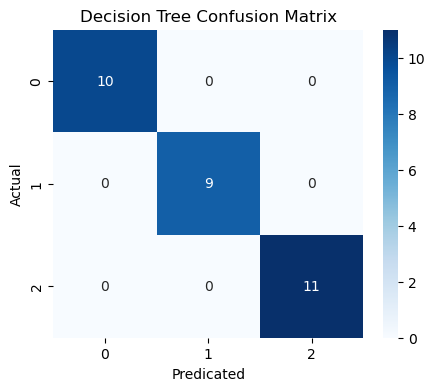

In [13]:
# Decision Tree Confusion Matrix Heatmap

plt.figure(figsize = (5,4))
sns.heatmap(cm1,annot = True,cmap ="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicated")
plt.ylabel("Actual")

Text(33.22222222222222, 0.5, 'Actual')

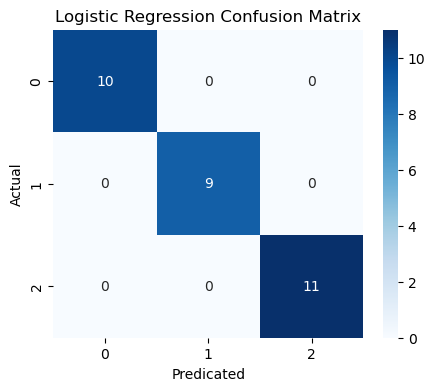

In [14]:
# Logistic Regression Confusion Matrix Heatmap

plt.figure(figsize = (5,4))
sns.heatmap(cm1,annot = True,cmap ="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicated")
plt.ylabel("Actual")

In [15]:
print("\nFinal Comparison:")
print("Decision Tree Accuracy:", acc1)
print("Logistic Regression Accuracy:", acc2)


Final Comparison:
Decision Tree Accuracy: 1.0
Logistic Regression Accuracy: 1.0
